# Обучение head-only RuBERT для multi-label классификации отзывов

Этот ноутбук обучает первый вариант модели:

```text
RuBERT / BERT-like encoder
+
замороженные веса encoder
+
Dropout
+
Linear(hidden_size → 13)
```

То есть обучается только простая классификационная голова сверху, а сама языковая модель не дообучается.

Задача: **multi-label классификация** на 13 классов. Один отзыв может относиться сразу к нескольким классам.

Данные для обучения берутся из папок:

```text
data/labeled/wb_feedbacks_llm_labeled_from_clusters
data/labeled/wb_feedbacks_llm_labeled_from_sample
```

Валидация / финальная оценка делается на:

```text
data/labeled/golden_set_by_class
```


In [1]:
# Если запускаешь в Google Colab, сначала подключи Google Drive

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
!pip install -q --no-cache-dir --force-reinstall \
  "numpy==2.0.2" \
  "pandas==2.2.2" \
  "scipy==1.14.1" \
  "scikit-learn==1.5.2" \
  "pyarrow==18.1.0" \
  "transformers==4.44.2" \
  "accelerate==0.33.0" \
  "sentencepiece==0.2.0" \
  "safetensors==0.4.5" \
  "tokenizers==0.19.1" \
  "tqdm==4.67.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 102.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 327.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 181.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 204.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 160.7 MB/s eta 0:00:00
ERROR: Cannot install accelerate==0.33.0, numpy==2.0.2, pandas==2.2.2, scikit-learn==1.5.2, scipy==1.14.1 and transformers==4.44.2 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [3]:
import ast
import json
import os
import random
import re
from pathlib import Path

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    hamming_loss,
    jaccard_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("device:", DEVICE)


numpy: 2.0.2
pandas: 2.2.2
torch: 2.11.0+cu128
device: cuda


In [4]:
# =========================
# Основные настройки
# =========================

BASE_DIR = Path("/content/drive/MyDrive/MLops_project/project")

TRAIN_DIRS = [
    BASE_DIR / "data" / "labeled" / "wb_feedbacks_llm_labeled_from_clusters",
    BASE_DIR / "data" / "labeled" / "wb_feedbacks_llm_labeled_from_sample",
]

GOLDEN_DIR = BASE_DIR / "data" / "labeled" / "golden_set_by_class"

OUTPUT_DIR = BASE_DIR / "models" / "rubert_head_only_multilabel"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = BASE_DIR / "reports" / "rubert_head_only_multilabel"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Основная модель. Для более быстрого теста можно заменить на:
# MODEL_NAME = "cointegrated/rubert-tiny2"
MODEL_NAME = "DeepPavlov/rubert-base-cased"

MAX_LENGTH = 192
BATCH_SIZE = 16
EPOCHS = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.01
DROPOUT = 0.2
VALID_SIZE = 0.2
PATIENCE = 2

# Нужно ли учитывать дисбаланс классов в loss
USE_POS_WEIGHT = True

# Если Colab падает по памяти, поставь BATCH_SIZE = 8.


In [5]:
ALLOWED_LABELS = [
    "Брак / дефект товара",
    "Низкое качество материала",
    "Проблема с размером / посадкой",
    "Несоответствие описанию",
    "Несоответствие ожиданиям / эффекту",
    "Проблема с комплектацией",
    "Проблема с упаковкой",
    "Проблема доставки / получения",
    "Цена / ценность",
    "Подделка / оригинальность",
    "Положительный отзыв",
    "Нейтральный / информационный отзыв",
    "Другая проблема",
]

LABEL2ID = {label: i for i, label in enumerate(ALLOWED_LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

NUM_LABELS = len(ALLOWED_LABELS)
NUM_LABELS


13

In [6]:
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def find_text_column(df):
    candidates = [
        "text", "review", "отзыв", "feedback", "comment", "content",
        "review_text", "Текст", "Текст отзыва"
    ]
    for col in candidates:
        if col in df.columns:
            return col

    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    best_col = None
    best_len = -1
    for col in object_cols:
        avg_len = df[col].dropna().astype(str).str.len().mean()
        if avg_len > best_len:
            best_len = avg_len
            best_col = col

    if best_col is None:
        raise ValueError("Не удалось найти колонку с текстом.")
    return best_col


def find_labels_column(df):
    candidates = [
        "labels", "label", "classes", "class", "llm_labels",
        "predicted_labels", "Разметка", "Классы"
    ]
    for col in candidates:
        if col in df.columns:
            return col

    label_cols = [label for label in ALLOWED_LABELS if label in df.columns]
    if label_cols:
        return None

    raise ValueError("Не удалось найти колонку с labels и отдельные class columns.")


def parse_labels(value):
    if value is None:
        return []

    if isinstance(value, list):
        raw_items = value
    elif pd.isna(value):
        return []
    else:
        s = str(value).strip()
        if not s:
            return []

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                raw_items = parsed
            elif isinstance(parsed, dict):
                raw_items = parsed.get("labels", [])
            else:
                raw_items = [str(parsed)]
        except Exception:
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    raw_items = parsed
                elif isinstance(parsed, dict):
                    raw_items = parsed.get("labels", [])
                else:
                    raw_items = [str(parsed)]
            except Exception:
                raw_items = re.split(r"[;,|]", s)

    labels = []
    for item in raw_items:
        label = str(item).strip().strip('"').strip("'")
        if label in LABEL2ID:
            labels.append(label)

    seen = set()
    result = []
    for label in labels:
        if label not in seen:
            result.append(label)
            seen.add(label)
    return result


def labels_to_multihot(labels):
    y = np.zeros(NUM_LABELS, dtype=np.float32)
    for label in labels:
        if label in LABEL2ID:
            y[LABEL2ID[label]] = 1.0
    return y


def load_csv_file(path):
    df = pd.read_csv(path)

    text_col = find_text_column(df)
    labels_col = find_labels_column(df)

    rows = []
    for _, row in df.iterrows():
        text = normalize_text(row[text_col])
        if not text:
            continue

        if labels_col is None:
            labels = []
            for label in ALLOWED_LABELS:
                try:
                    if int(row[label]) == 1:
                        labels.append(label)
                except Exception:
                    pass
        else:
            labels = parse_labels(row[labels_col])

        if not labels:
            continue

        rows.append({
            "text": text,
            "labels": labels,
            "source_file": str(path),
        })

    return pd.DataFrame(rows)


def load_labeled_dir(directory, prefer_stacked=False):
    directory = Path(directory)
    if not directory.exists():
        print(f"Папка не найдена: {directory}")
        return pd.DataFrame(columns=["text", "labels", "source_file"])

    csv_paths = sorted(directory.glob("*.csv"))

    if prefer_stacked:
        stacked = directory / "golden_set_all_classes_stacked.csv"
        if stacked.exists():
            csv_paths = [stacked]
        else:
            csv_paths = [
                p for p in csv_paths
                if "summary" not in p.name.lower()
                and "counts" not in p.name.lower()
                and "saved_files" not in p.name.lower()
            ]
    else:
        csv_paths = [
            p for p in csv_paths
            if "summary" not in p.name.lower()
            and "counts" not in p.name.lower()
            and "saved_files" not in p.name.lower()
            and "class_status" not in p.name.lower()
            and "run_stats" not in p.name.lower()
        ]

    frames = []
    for path in csv_paths:
        try:
            part = load_csv_file(path)
            if len(part) > 0:
                frames.append(part)
            print(f"OK: {path.name}: {len(part)} строк")
        except Exception as e:
            print(f"SKIP: {path.name}: {e}")

    if not frames:
        return pd.DataFrame(columns=["text", "labels", "source_file"])

    df = pd.concat(frames, ignore_index=True)

    grouped = []
    for text, group in df.groupby("text", sort=False):
        label_set = []
        seen = set()
        for labels in group["labels"]:
            for label in labels:
                if label not in seen:
                    label_set.append(label)
                    seen.add(label)
        grouped.append({
            "text": text,
            "labels": label_set,
            "source_file": " | ".join(sorted(set(group["source_file"].astype(str)))),
        })

    return pd.DataFrame(grouped)


In [7]:
# Загружаем train-данные из двух папок

train_frames = []
for directory in TRAIN_DIRS:
    print("=" * 120)
    print("Загрузка:", directory)
    part = load_labeled_dir(directory, prefer_stacked=False)
    print("Итого из папки:", len(part))
    if len(part) > 0:
        train_frames.append(part)

if not train_frames:
    raise FileNotFoundError(
        "Не найдено ни одной строки для train. Проверь BASE_DIR и папки TRAIN_DIRS:\n"
        + "\n".join(str(p) for p in TRAIN_DIRS)
    )

train_df = pd.concat(train_frames, ignore_index=True)

# Объединяем дубликаты по тексту между двумя папками
dedup_rows = []
for text, group in train_df.groupby("text", sort=False):
    label_set = []
    seen = set()
    for labels in group["labels"]:
        for label in labels:
            if label not in seen:
                label_set.append(label)
                seen.add(label)
    dedup_rows.append({
        "text": text,
        "labels": label_set,
        "source_file": " | ".join(sorted(set(group["source_file"].astype(str)))),
    })

train_df = pd.DataFrame(dedup_rows)
train_df["y"] = train_df["labels"].apply(labels_to_multihot)

print("Train before golden leakage removal:", len(train_df))
train_df.head()


Загрузка: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_llm_labeled_from_clusters
OK: extra_from_hdbscan_candidate_clusters.csv: 866 строк
OK: extra_from_hdbscan_candidate_clusters_final.csv: 866 строк
Итого из папки: 866
Загрузка: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_llm_labeled_from_sample
OK: balanced_50_per_class_random_chunks.csv: 146 строк
OK: balanced_50_per_class_random_chunks_final.csv: 146 строк
Итого из папки: 146
Train before golden leakage removal: 1012


,text,labels,source_file,y
0,"Забрала пиджак,пришла домой оказался мал,верну...",[Проблема доставки / получения],/content/drive/MyDrive/MLops_project/project/d...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1,"Чехол не налез на телефон, ещё и за возврат 10...","[Проблема с размером / посадкой, Цена / ценность]",/content/drive/MyDrive/MLops_project/project/d...,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
2,второй раз присылают просроченный товар!!! тре...,[Другая проблема],/content/drive/MyDrive/MLops_project/project/d...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"Не стОит конечно таких денег,развязывается ,кр...",[Цена / ценность],/content/drive/MyDrive/MLops_project/project/d...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
4,Написана было две батарейки а пришла одна 😢,[Проблема с комплектацией],/content/drive/MyDrive/MLops_project/project/d...,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [8]:
# Загружаем golden set

golden_df = load_labeled_dir(GOLDEN_DIR, prefer_stacked=True)

if len(golden_df) == 0:
    raise FileNotFoundError(
        "Golden set не найден или пустой. Проверь GOLDEN_DIR:\n"
        f"{GOLDEN_DIR}"
    )

golden_df["y"] = golden_df["labels"].apply(labels_to_multihot)

print("Golden rows:", len(golden_df))
golden_df.head()


OK: golden_set_all_classes_stacked.csv: 984 строк
Golden rows: 761


,text,labels,source_file,y
0,Бокалы пришли в рванной коробке и один бокал с...,"[Брак / дефект товара, Низкое качество материа...",/content/drive/MyDrive/MLops_project/project/d...,"[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
1,"Маловероятно, ещё и с затяжками. Не захотели в...",[Брак / дефект товара],/content/drive/MyDrive/MLops_project/project/d...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Заказ шёл долго. Катушки сломанные пришли. Нет...,"[Проблема доставки / получения, Брак / дефект ...",/content/drive/MyDrive/MLops_project/project/d...,"[1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, ..."
3,"Пришёл товар разбитый, это вообще что? Знают ч...","[Брак / дефект товара, Проблема с упаковкой]",/content/drive/MyDrive/MLops_project/project/d...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
4,Никакой фирменной упаковки. Пришло в обычном п...,"[Проблема с упаковкой, Подделка / оригинальнос...",/content/drive/MyDrive/MLops_project/project/d...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."


In [9]:
# Убираем из train все тексты, которые есть в golden set, чтобы не было утечки

golden_texts = set(golden_df["text"].astype(str))
before = len(train_df)
train_df = train_df[~train_df["text"].astype(str).isin(golden_texts)].reset_index(drop=True)
after = len(train_df)

print(f"Удалено из train из-за совпадения с golden: {before - after}")
print("Train after leakage removal:", len(train_df))


Удалено из train из-за совпадения с golden: 761
Train after leakage removal: 251


In [10]:
def class_counts(df, y_col="y"):
    if len(df) == 0:
        return pd.DataFrame({"label": ALLOWED_LABELS, "count": [0] * NUM_LABELS})

    Y = np.stack(df[y_col].values)
    counts = Y.sum(axis=0).astype(int)
    return pd.DataFrame({
        "label": ALLOWED_LABELS,
        "count": counts,
        "share": counts / len(df),
    })


train_counts = class_counts(train_df)
golden_counts = class_counts(golden_df)

display(train_counts)
display(golden_counts)

train_counts.to_csv(REPORTS_DIR / "train_class_counts.csv", index=False)
golden_counts.to_csv(REPORTS_DIR / "golden_class_counts.csv", index=False)


,label,count,share
0,Брак / дефект товара,63,0.250996
1,Низкое качество материала,0,0.000000
2,Проблема с размером / посадкой,0,0.000000
3,Несоответствие описанию,47,0.187251
4,Несоответствие ожиданиям / эффекту,14,0.055777
5,Проблема с комплектацией,40,0.159363
6,Проблема с упаковкой,115,0.458167
7,Проблема доставки / получения,21,0.083665
8,Цена / ценность,0,0.000000
9,Подделка / оригинальность,0,0.000000


,label,count,share
0,Брак / дефект товара,152,0.199737
1,Низкое качество материала,56,0.073587
2,Проблема с размером / посадкой,54,0.070959
3,Несоответствие описанию,128,0.168200
4,Несоответствие ожиданиям / эффекту,111,0.145861
5,Проблема с комплектацией,131,0.172142
6,Проблема с упаковкой,203,0.266754
7,Проблема доставки / получения,119,0.156373
8,Цена / ценность,78,0.102497
9,Подделка / оригинальность,18,0.023653


## Визуализации

Ниже добавлены графики, которые автоматически сохраняются в `reports/rubert_head_only_multilabel/figures`. Они помогают быстро посмотреть баланс классов, динамику обучения, подобранные пороги и качество по каждому классу.

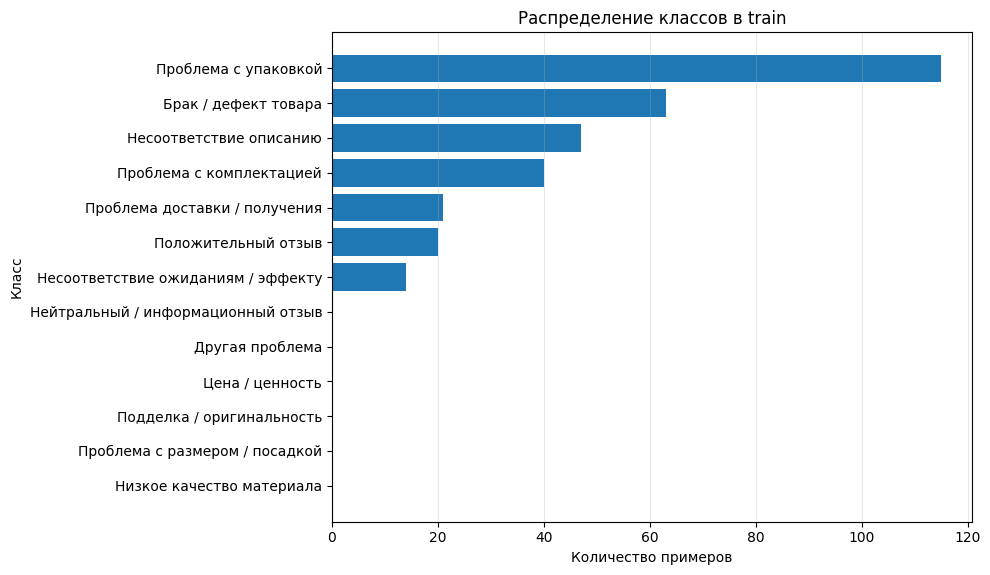

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/train_class_distribution.png


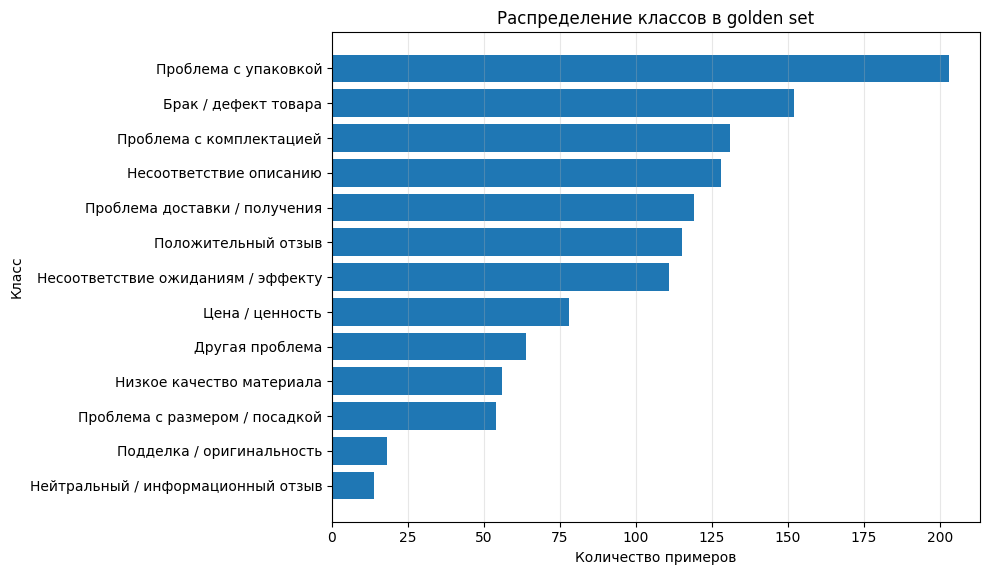

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/golden_class_distribution.png


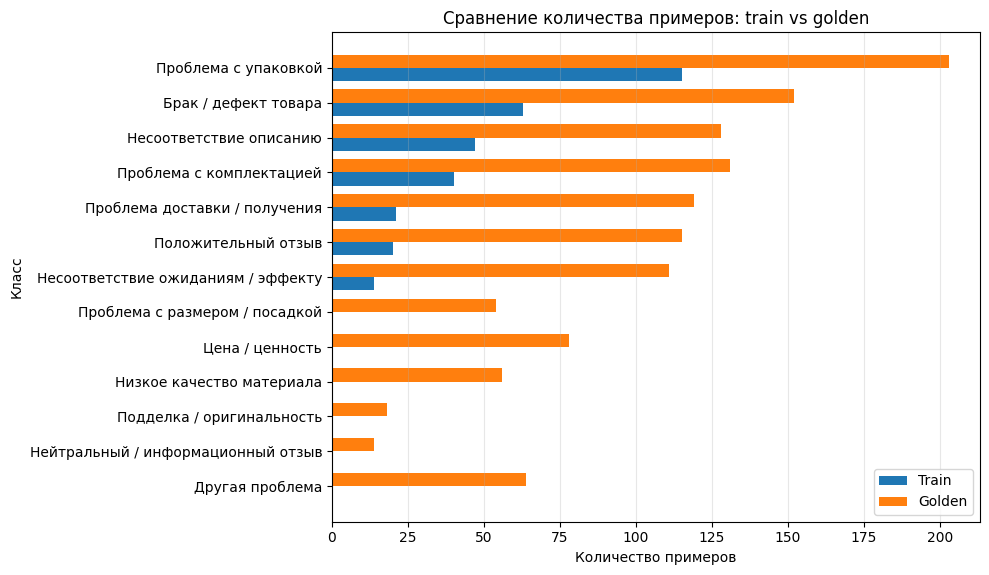

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/train_vs_golden_class_distribution.png


In [11]:
# =========================
# Графики распределения классов
# =========================

FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_current_fig(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("График сохранен:", path)


def plot_horizontal_bar(df, value_col, title, xlabel, filename, label_col="label", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)

    plt.figure(figsize=(10, max(5, 0.45 * len(plot_df))))
    plt.barh(plot_df[label_col], plot_df[value_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Класс")
    plt.grid(axis="x", alpha=0.3)
    save_current_fig(filename)


plot_horizontal_bar(
    train_counts,
    value_col="count",
    title="Распределение классов в train",
    xlabel="Количество примеров",
    filename="train_class_distribution.png",
)

plot_horizontal_bar(
    golden_counts,
    value_col="count",
    title="Распределение классов в golden set",
    xlabel="Количество примеров",
    filename="golden_class_distribution.png",
)

counts_compare = train_counts[["label", "count"]].rename(columns={"count": "train_count"}).merge(
    golden_counts[["label", "count"]].rename(columns={"count": "golden_count"}),
    on="label",
    how="outer",
).fillna(0)
counts_compare = counts_compare.sort_values("train_count", ascending=True)

plt.figure(figsize=(10, max(5, 0.45 * len(counts_compare))))
y_pos = np.arange(len(counts_compare))
bar_height = 0.38
plt.barh(y_pos - bar_height / 2, counts_compare["train_count"], height=bar_height, label="Train")
plt.barh(y_pos + bar_height / 2, counts_compare["golden_count"], height=bar_height, label="Golden")
plt.yticks(y_pos, counts_compare["label"])
plt.title("Сравнение количества примеров: train vs golden")
plt.xlabel("Количество примеров")
plt.ylabel("Класс")
plt.grid(axis="x", alpha=0.3)
plt.legend()
save_current_fig("train_vs_golden_class_distribution.png")


In [12]:
# Делим train на train/validation.
# Golden set остается отдельно для финальной оценки.

if len(train_df) < 2:
    raise ValueError("После удаления утечек в train осталось меньше 2 строк. Нельзя сделать train/validation split.")

train_part, val_part = train_test_split(
    train_df,
    test_size=VALID_SIZE,
    random_state=SEED,
    shuffle=True,
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

print("Train part:", len(train_part))
print("Val part:", len(val_part))
print("Golden:", len(golden_df))


Train part: 200
Val part: 51
Golden: 761


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ReviewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts = df["text"].astype(str).tolist()
        self.labels = np.stack(df["y"].values).astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


train_dataset = ReviewsDataset(train_part, tokenizer, MAX_LENGTH)
val_dataset = ReviewsDataset(val_part, tokenizer, MAX_LENGTH)
golden_dataset = ReviewsDataset(golden_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
golden_loader = DataLoader(golden_dataset, batch_size=BATCH_SIZE, shuffle=False)


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
class BertHeadOnlyMultiLabelClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_labels),
        )

        # Head-only режим: замораживаем BERT/RuBERT encoder
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_embedding)
        return logits


model = BertHeadOnlyMultiLabelClassifier(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", total_params)
print("Trainable params:", trainable_params)
print("Trainable share:", trainable_params / total_params)


pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Total params: 177863437
Trainable params: 9997
Trainable share: 5.620604306662532e-05


In [15]:
# pos_weight для учета дисбаланса классов

Y_train = np.stack(train_part["y"].values)
positive_counts = Y_train.sum(axis=0)
negative_counts = len(Y_train) - positive_counts

pos_weight_np = negative_counts / np.clip(positive_counts, 1, None)
pos_weight_np = np.clip(pos_weight_np, 1.0, 50.0)

pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32).to(DEVICE)

if USE_POS_WEIGHT:
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    criterion = nn.BCEWithLogitsLoss()

pd.DataFrame({
    "label": ALLOWED_LABELS,
    "positive_count": positive_counts.astype(int),
    "negative_count": negative_counts.astype(int),
    "pos_weight": pos_weight_np,
})


,label,positive_count,negative_count,pos_weight
0,Брак / дефект товара,54,146,2.703704
1,Низкое качество материала,0,200,50.000000
2,Проблема с размером / посадкой,0,200,50.000000
3,Несоответствие описанию,34,166,4.882353
4,Несоответствие ожиданиям / эффекту,10,190,19.000000
5,Проблема с комплектацией,33,167,5.060606
6,Проблема с упаковкой,88,112,1.272727
7,Проблема доставки / получения,17,183,10.764706
8,Цена / ценность,0,200,50.000000
9,Подделка / оригинальность,0,200,50.000000


In [16]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

num_training_steps = EPOCHS * len(train_loader)
if num_training_steps <= 0:
    raise ValueError("train_loader пустой: проверь, что train_part не пустой и BATCH_SIZE задан корректно.")

num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print("Training steps:", num_training_steps)
print("Warmup steps:", num_warmup_steps)


Training steps: 78
Warmup steps: 7


In [17]:
def predict_proba(model, loader):
    model.eval()
    all_probs = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * input_ids.size(0)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets)
    avg_loss = total_loss / len(loader.dataset)

    return y_true, y_prob, avg_loss


def binarize_with_thresholds(y_prob, thresholds):
    return (y_prob >= thresholds.reshape(1, -1)).astype(int)


def compute_metrics(y_true, y_prob, thresholds=None, prefix=""):
    if thresholds is None:
        thresholds = np.full(NUM_LABELS, 0.5)

    y_pred = binarize_with_thresholds(y_prob, thresholds)

    metrics = {
        f"{prefix}micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        f"{prefix}samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        f"{prefix}micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}hamming_loss": hamming_loss(y_true, y_pred),
        f"{prefix}jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
        f"{prefix}jaccard_macro": jaccard_score(y_true, y_pred, average="macro", zero_division=0),
    }

    try:
        metrics[f"{prefix}roc_auc_micro"] = roc_auc_score(y_true, y_prob, average="micro")
    except Exception:
        metrics[f"{prefix}roc_auc_micro"] = np.nan

    try:
        metrics[f"{prefix}roc_auc_macro"] = roc_auc_score(y_true, y_prob, average="macro")
    except Exception:
        metrics[f"{prefix}roc_auc_macro"] = np.nan

    try:
        metrics[f"{prefix}pr_auc_micro"] = average_precision_score(y_true, y_prob, average="micro")
    except Exception:
        metrics[f"{prefix}pr_auc_micro"] = np.nan

    try:
        metrics[f"{prefix}pr_auc_macro"] = average_precision_score(y_true, y_prob, average="macro")
    except Exception:
        metrics[f"{prefix}pr_auc_macro"] = np.nan

    return metrics


def per_class_metrics_df(y_true, y_prob, thresholds, split_name):
    y_pred = binarize_with_thresholds(y_prob, thresholds)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0,
    )

    rows = []
    for i, label in enumerate(ALLOWED_LABELS):
        try:
            roc_auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true[:, i], y_prob[:, i])
        except Exception:
            pr_auc = np.nan

        rows.append({
            "split": split_name,
            "label": label,
            "threshold": thresholds[i],
            "support": int(support[i]),
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        })

    return pd.DataFrame(rows)


def tune_thresholds(y_true, y_prob):
    thresholds = np.zeros(NUM_LABELS, dtype=np.float32)
    rows = []
    grid = np.arange(0.05, 0.96, 0.05)

    for i, label in enumerate(ALLOWED_LABELS):
        best_thr = 0.5
        best_f1 = -1.0

        for thr in grid:
            pred_i = (y_prob[:, i] >= thr).astype(int)
            f1_i = f1_score(y_true[:, i], pred_i, zero_division=0)

            if f1_i > best_f1:
                best_f1 = f1_i
                best_thr = float(thr)

        thresholds[i] = best_thr
        rows.append({
            "label": label,
            "best_threshold": best_thr,
            "best_val_f1": best_f1,
            "support_val": int(y_true[:, i].sum()),
        })

    return thresholds, pd.DataFrame(rows)


In [18]:
# Обучение

history = []
best_val_macro_f1 = -1.0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item() * input_ids.size(0)
        pbar.set_postfix({"loss": loss.item()})

    train_loss = train_loss / len(train_loader.dataset)

    y_val_true, y_val_prob, val_loss = predict_proba(model, val_loader)
    val_metrics_05 = compute_metrics(y_val_true, y_val_prob, thresholds=None, prefix="val_")

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **val_metrics_05,
    }
    history.append(row)

    print(
        f"Epoch {epoch}: "
        f"train_loss={train_loss:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_macro_f1@0.5={val_metrics_05['val_macro_f1']:.4f}, "
        f"val_micro_f1@0.5={val_metrics_05['val_micro_f1']:.4f}"
    )

    current_score = val_metrics_05["val_macro_f1"]
    if current_score > best_val_macro_f1:
        best_val_macro_f1 = current_score
        best_state = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_val_macro_f1": best_val_macro_f1,
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}")
        break

history_df = pd.DataFrame(history)
display(history_df)
history_df.to_csv(REPORTS_DIR / "training_history.csv", index=False)

if best_state is not None:
    model.load_state_dict(best_state["model_state_dict"])
    print("Loaded best model from epoch:", best_state["epoch"])


Epoch 1/6:   0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: train_loss=0.8894, val_loss=0.7609, val_macro_f1@0.5=0.1542, val_micro_f1@0.5=0.3797


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_r

Epoch 2/6:   0%|          | 0/13 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5: train_loss=0.5933, val_loss=0.6304, val_macro_f1@0.5=0.1867, val_micro_f1@0.5=0.4020
Early stopping на эпохе 5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_r

,epoch,train_loss,val_loss,val_micro_f1,val_macro_f1,val_weighted_f1,val_samples_f1,val_micro_precision,val_macro_precision,val_micro_recall,val_macro_recall,val_hamming_loss,val_jaccard_micro,val_jaccard_macro,val_roc_auc_micro,val_roc_auc_macro,val_pr_auc_micro,val_pr_auc_macro
0,1,0.889380,0.760858,0.379747,0.154184,0.415187,0.378525,0.266272,0.111879,0.661765,0.288297,0.221719,0.234375,0.099500,0.842536,NaN,0.344140,0.168248
1,2,0.682459,0.670439,0.346939,0.127014,0.385444,0.312885,0.265625,0.106279,0.500000,0.210153,0.193062,0.209877,0.080787,0.831364,NaN,0.303630,0.222691
2,3,0.625169,0.645977,0.407080,0.211403,0.485401,0.398880,0.291139,0.180093,0.676471,0.339650,0.202112,0.255556,0.139786,0.838433,NaN,0.324250,0.228642
3,4,0.608206,0.634758,0.398190,0.185830,0.456338,0.390289,0.287582,0.146320,0.647059,0.301188,0.200603,0.248588,0.119618,0.856723,NaN,0.390885,0.236087
4,5,0.593268,0.630409,0.401961,0.186717,0.455264,0.405882,0.301471,0.147454,0.602941,0.286231,0.184012,0.251534,0.121662,0.853164,NaN,0.396394,0.230877


Loaded best model from epoch: 3


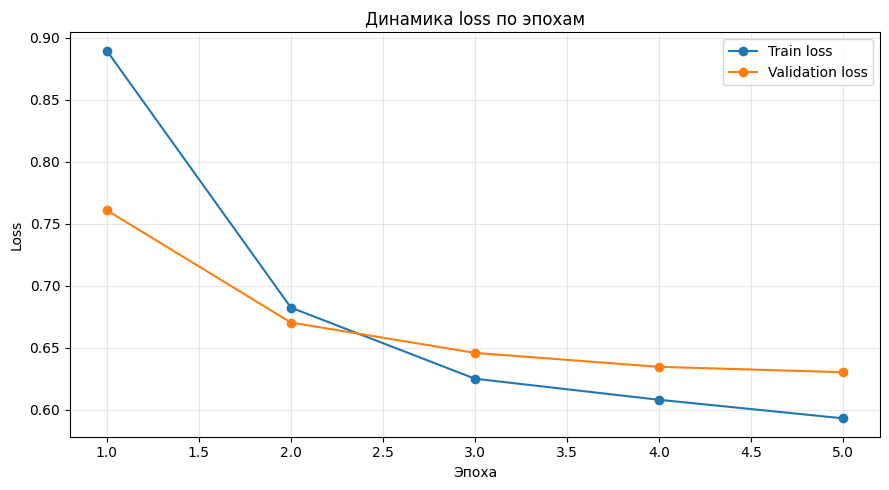

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/training_loss_curve.png


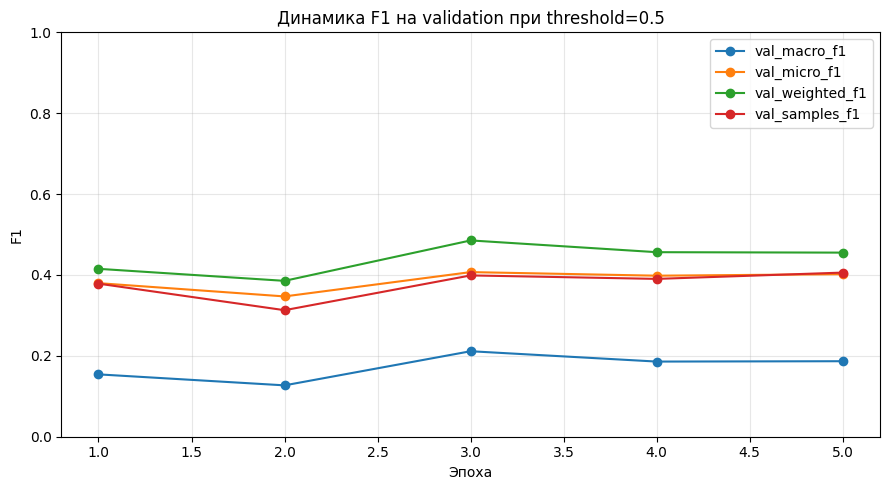

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/validation_f1_curve.png


In [19]:
# =========================
# Графики обучения
# =========================

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.title("Динамика loss по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
save_current_fig("training_loss_curve.png")

metric_cols = [
    col for col in ["val_macro_f1", "val_micro_f1", "val_weighted_f1", "val_samples_f1"]
    if col in history_df.columns
]

plt.figure(figsize=(9, 5))
for col in metric_cols:
    plt.plot(history_df["epoch"], history_df[col], marker="o", label=col)
plt.title("Динамика F1 на validation при threshold=0.5")
plt.xlabel("Эпоха")
plt.ylabel("F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
save_current_fig("validation_f1_curve.png")


In [20]:
# Подбираем пороги по validation set

y_val_true, y_val_prob, val_loss = predict_proba(model, val_loader)

thresholds, thresholds_df = tune_thresholds(y_val_true, y_val_prob)
display(thresholds_df)

thresholds_df.to_csv(REPORTS_DIR / "thresholds_by_class.csv", index=False)

with open(REPORTS_DIR / "thresholds.json", "w", encoding="utf-8") as f:
    json.dump(
        {label: float(thresholds[i]) for i, label in enumerate(ALLOWED_LABELS)},
        f,
        ensure_ascii=False,
        indent=2,
    )


  0%|          | 0/4 [00:00<?, ?it/s]

,label,best_threshold,best_val_f1,support_val
0,Брак / дефект товара,0.45,0.310345,9
1,Низкое качество материала,0.05,0.000000,0
2,Проблема с размером / посадкой,0.05,0.000000,0
3,Несоответствие описанию,0.40,0.426230,13
4,Несоответствие ожиданиям / эффекту,0.45,0.272727,4
5,Проблема с комплектацией,0.45,0.254545,7
6,Проблема с упаковкой,0.40,0.701299,27
7,Проблема доставки / получения,0.55,0.571429,4
8,Цена / ценность,0.05,0.000000,0
9,Подделка / оригинальность,0.05,0.000000,0


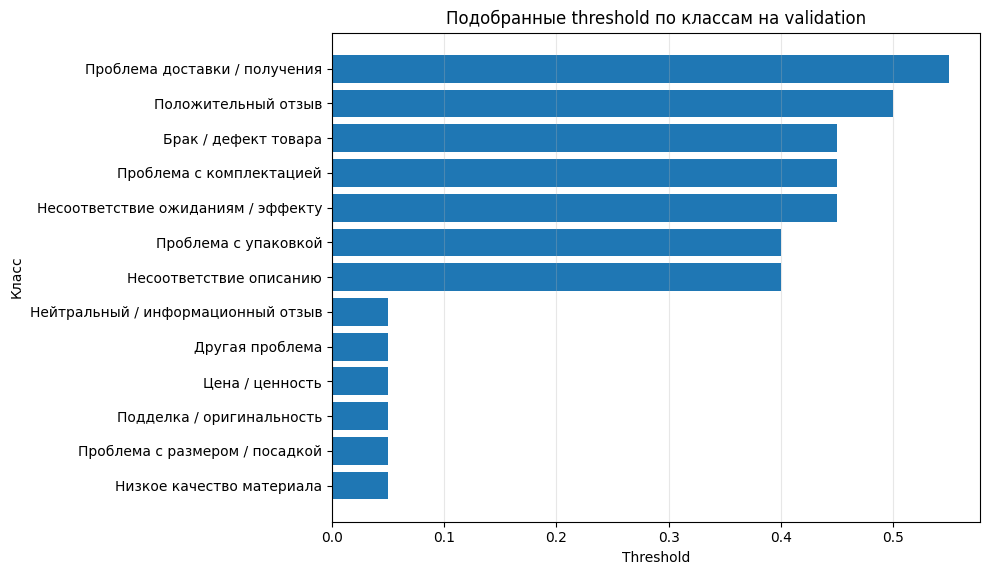

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/thresholds_by_class.png


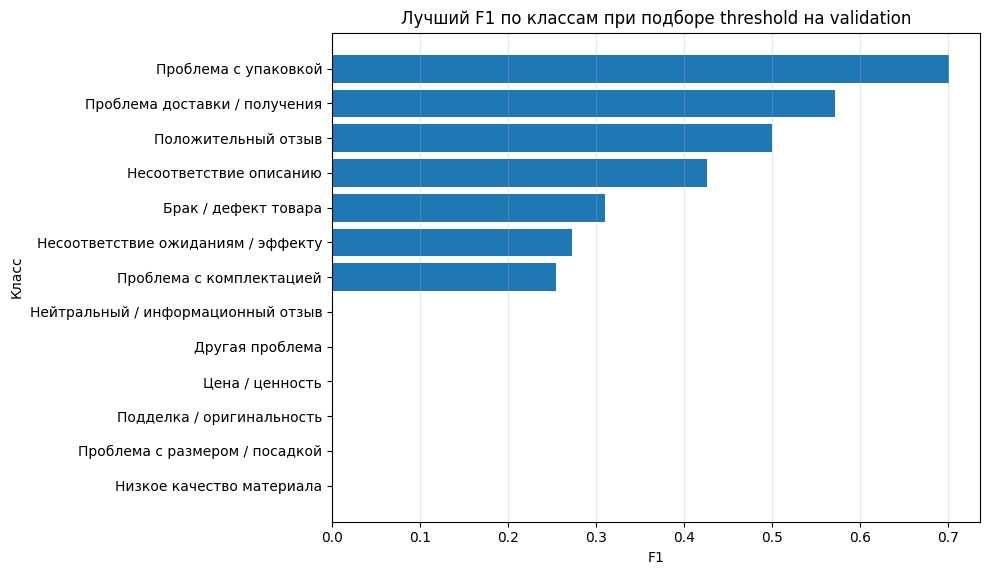

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/best_val_f1_by_class_threshold_tuning.png


In [21]:
# =========================
# График подобранных порогов
# =========================

plot_horizontal_bar(
    thresholds_df,
    value_col="best_threshold",
    title="Подобранные threshold по классам на validation",
    xlabel="Threshold",
    filename="thresholds_by_class.png",
)

plot_horizontal_bar(
    thresholds_df,
    value_col="best_val_f1",
    title="Лучший F1 по классам при подборе threshold на validation",
    xlabel="F1",
    filename="best_val_f1_by_class_threshold_tuning.png",
)


In [22]:
# Метрики на validation после подбора порогов

val_metrics_tuned = compute_metrics(y_val_true, y_val_prob, thresholds=thresholds, prefix="val_tuned_")
val_per_class = per_class_metrics_df(y_val_true, y_val_prob, thresholds, split_name="validation")

display(pd.DataFrame([val_metrics_tuned]))
display(val_per_class)

pd.DataFrame([val_metrics_tuned]).to_csv(REPORTS_DIR / "validation_metrics_tuned.csv", index=False)
val_per_class.to_csv(REPORTS_DIR / "validation_per_class_metrics.csv", index=False)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_r

,val_tuned_micro_f1,val_tuned_macro_f1,val_tuned_weighted_f1,val_tuned_samples_f1,val_tuned_micro_precision,val_tuned_macro_precision,val_tuned_micro_recall,val_tuned_macro_recall,val_tuned_hamming_loss,val_tuned_jaccard_micro,val_tuned_jaccard_macro,val_tuned_roc_auc_micro,val_tuned_roc_auc_macro,val_tuned_pr_auc_micro,val_tuned_pr_auc_macro
0,0.398754,0.233583,0.506288,0.404139,0.252964,0.180667,0.941176,0.461538,0.291101,0.249027,0.156274,0.853164,NaN,0.396394,0.230877


,split,label,threshold,support,precision,recall,f1,roc_auc,pr_auc
0,validation,Брак / дефект товара,0.45,9,0.183673,1.00,0.310345,0.494709,0.360891
1,validation,Низкое качество материала,0.05,0,0.000000,0.00,0.000000,NaN,0.000000
2,validation,Проблема с размером / посадкой,0.05,0,0.000000,0.00,0.000000,NaN,0.000000
3,validation,Несоответствие описанию,0.40,13,0.270833,1.00,0.426230,0.580972,0.374490
4,validation,Несоответствие ожиданиям / эффекту,0.45,4,0.166667,0.75,0.272727,0.760638,0.214057
5,validation,Проблема с комплектацией,0.45,7,0.145833,1.00,0.254545,0.581169,0.195677
6,validation,Проблема с упаковкой,0.40,27,0.540000,1.00,0.701299,0.655864,0.705653
7,validation,Проблема доставки / получения,0.55,4,0.666667,0.50,0.571429,0.744681,0.563508
8,validation,Цена / ценность,0.05,0,0.000000,0.00,0.000000,NaN,0.000000
9,validation,Подделка / оригинальность,0.05,0,0.000000,0.00,0.000000,NaN,0.000000


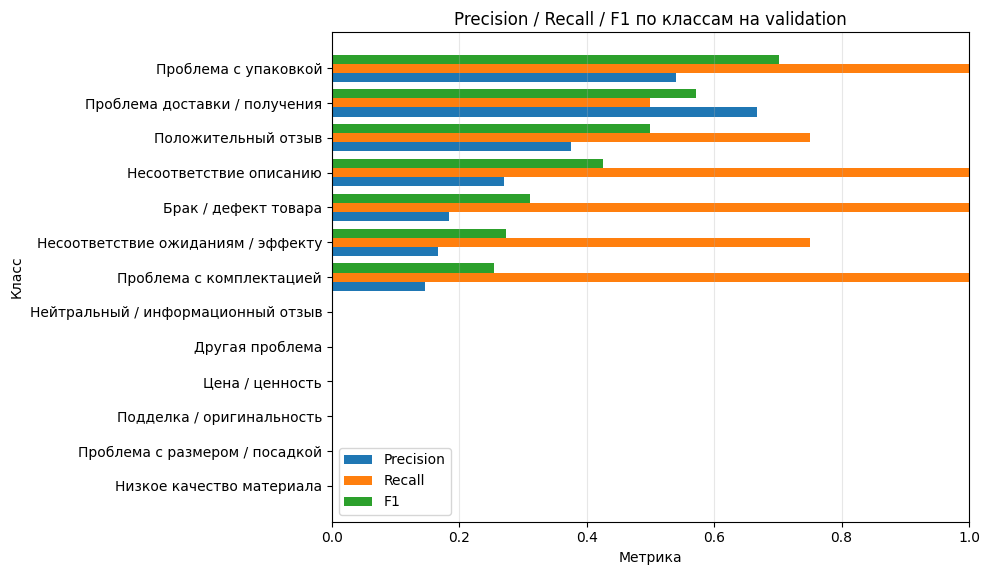

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/validation_precision_recall_f1_by_class.png


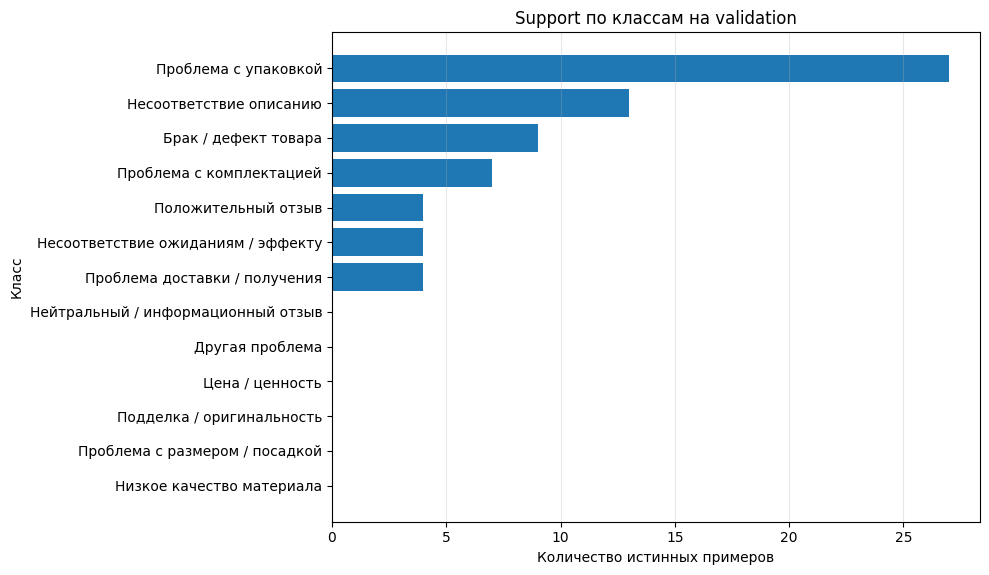

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/validation_support_by_class.png


In [23]:
# =========================
# Графики качества по классам на validation
# =========================

val_metrics_plot_df = val_per_class.sort_values("f1", ascending=True)

plt.figure(figsize=(10, max(5, 0.45 * len(val_metrics_plot_df))))
y_pos = np.arange(len(val_metrics_plot_df))
bar_height = 0.26
plt.barh(y_pos - bar_height, val_metrics_plot_df["precision"], height=bar_height, label="Precision")
plt.barh(y_pos, val_metrics_plot_df["recall"], height=bar_height, label="Recall")
plt.barh(y_pos + bar_height, val_metrics_plot_df["f1"], height=bar_height, label="F1")
plt.yticks(y_pos, val_metrics_plot_df["label"])
plt.title("Precision / Recall / F1 по классам на validation")
plt.xlabel("Метрика")
plt.ylabel("Класс")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.legend()
save_current_fig("validation_precision_recall_f1_by_class.png")

plot_horizontal_bar(
    val_per_class,
    value_col="support",
    title="Support по классам на validation",
    xlabel="Количество истинных примеров",
    filename="validation_support_by_class.png",
)


In [24]:
# Финальная оценка на golden set

y_gold_true, y_gold_prob, gold_loss = predict_proba(model, golden_loader)

gold_metrics_05 = compute_metrics(y_gold_true, y_gold_prob, thresholds=None, prefix="golden_05_")
gold_metrics_tuned = compute_metrics(y_gold_true, y_gold_prob, thresholds=thresholds, prefix="golden_tuned_")

gold_per_class_05 = per_class_metrics_df(
    y_gold_true,
    y_gold_prob,
    np.full(NUM_LABELS, 0.5),
    split_name="golden_threshold_0_5",
)

gold_per_class_tuned = per_class_metrics_df(
    y_gold_true,
    y_gold_prob,
    thresholds,
    split_name="golden_tuned_thresholds",
)

summary_metrics = {
    "golden_loss": gold_loss,
    **gold_metrics_05,
    **gold_metrics_tuned,
}

display(pd.DataFrame([summary_metrics]))
display(gold_per_class_tuned)

pd.DataFrame([summary_metrics]).to_csv(REPORTS_DIR / "golden_metrics_summary.csv", index=False)
gold_per_class_05.to_csv(REPORTS_DIR / "golden_per_class_metrics_threshold_0_5.csv", index=False)
gold_per_class_tuned.to_csv(REPORTS_DIR / "golden_per_class_metrics_tuned_thresholds.csv", index=False)


  0%|          | 0/48 [00:00<?, ?it/s]

,golden_loss,golden_05_micro_f1,golden_05_macro_f1,golden_05_weighted_f1,golden_05_samples_f1,golden_05_micro_precision,golden_05_macro_precision,golden_05_micro_recall,golden_05_macro_recall,golden_05_hamming_loss,...,golden_tuned_macro_precision,golden_tuned_micro_recall,golden_tuned_macro_recall,golden_tuned_hamming_loss,golden_tuned_jaccard_micro,golden_tuned_jaccard_macro,golden_tuned_roc_auc_micro,golden_tuned_roc_auc_macro,golden_tuned_pr_auc_micro,golden_tuned_pr_auc_macro
0,5.681553,0.314758,0.174247,0.259093,0.291174,0.254078,0.14131,0.413516,0.274805,0.226221,...,0.174128,0.613837,0.462223,0.386536,0.16634,0.122646,0.687199,0.556996,0.241553,0.186164


,split,label,threshold,support,precision,recall,f1,roc_auc,pr_auc
0,golden_tuned_thresholds,Брак / дефект товара,0.45,152,0.204482,0.960526,0.337182,0.556834,0.226844
1,golden_tuned_thresholds,Низкое качество материала,0.05,56,0.060284,0.303571,0.100592,0.454914,0.066695
2,golden_tuned_thresholds,Проблема с размером / посадкой,0.05,54,0.150000,0.222222,0.179104,0.541542,0.099105
3,golden_tuned_thresholds,Несоответствие описанию,0.40,128,0.165289,0.937500,0.281030,0.568313,0.221169
4,golden_tuned_thresholds,Несоответствие ожиданиям / эффекту,0.45,111,0.129825,0.333333,0.186869,0.473278,0.151071
5,golden_tuned_thresholds,Проблема с комплектацией,0.45,131,0.172176,0.954198,0.291715,0.478959,0.156544
6,golden_tuned_thresholds,Проблема с упаковкой,0.40,203,0.269333,0.995074,0.423924,0.675989,0.411418
7,golden_tuned_thresholds,Проблема доставки / получения,0.55,119,0.386364,0.142857,0.208589,0.710922,0.313261
8,golden_tuned_thresholds,Цена / ценность,0.05,78,0.088889,0.256410,0.132013,0.454406,0.103609
9,golden_tuned_thresholds,Подделка / оригинальность,0.05,18,0.000000,0.000000,0.000000,0.488261,0.023066


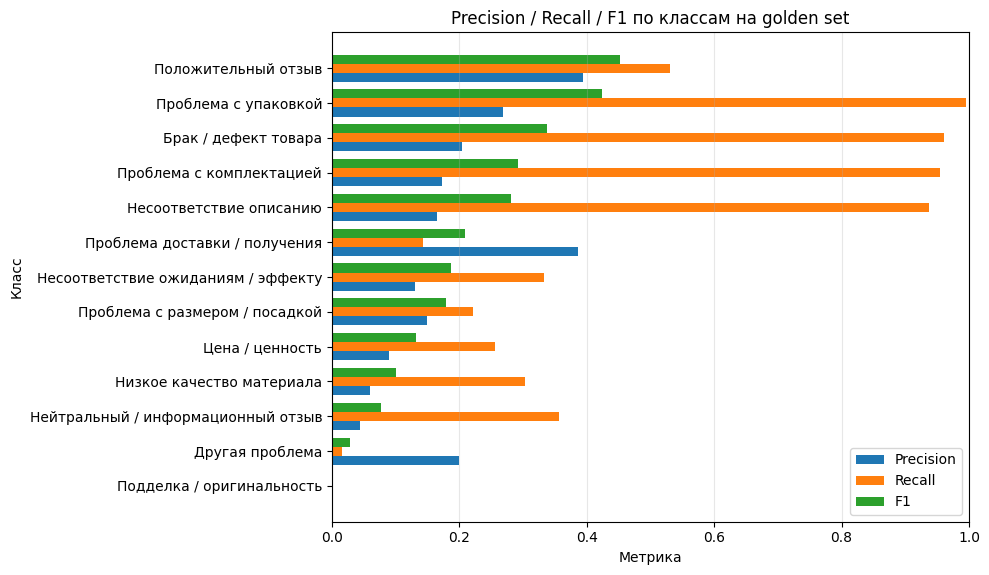

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/golden_precision_recall_f1_by_class.png


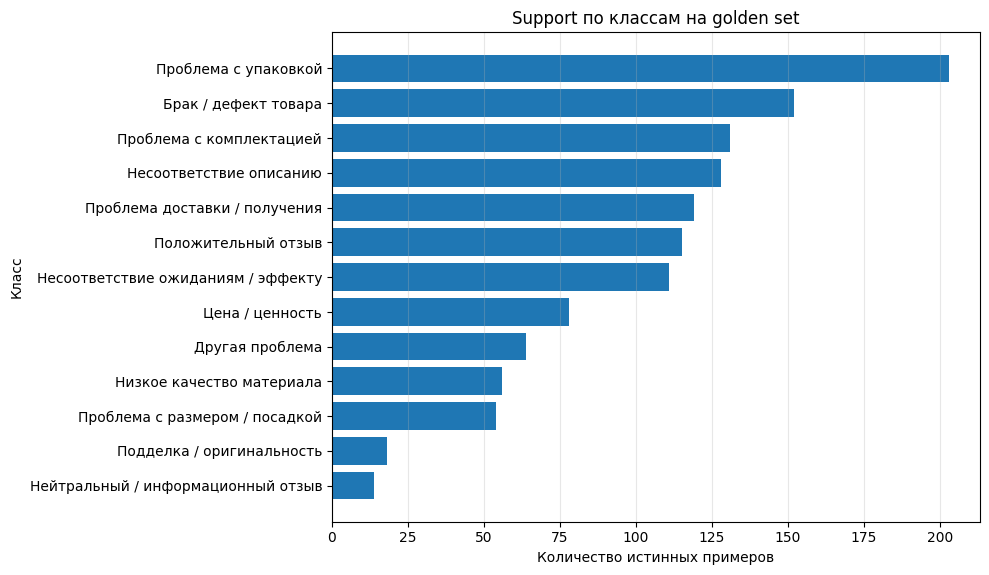

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/golden_support_by_class.png


In [25]:
# =========================
# Графики качества по классам на golden set
# =========================

gold_metrics_plot_df = gold_per_class_tuned.sort_values("f1", ascending=True)

plt.figure(figsize=(10, max(5, 0.45 * len(gold_metrics_plot_df))))
y_pos = np.arange(len(gold_metrics_plot_df))
bar_height = 0.26
plt.barh(y_pos - bar_height, gold_metrics_plot_df["precision"], height=bar_height, label="Precision")
plt.barh(y_pos, gold_metrics_plot_df["recall"], height=bar_height, label="Recall")
plt.barh(y_pos + bar_height, gold_metrics_plot_df["f1"], height=bar_height, label="F1")
plt.yticks(y_pos, gold_metrics_plot_df["label"])
plt.title("Precision / Recall / F1 по классам на golden set")
plt.xlabel("Метрика")
plt.ylabel("Класс")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.legend()
save_current_fig("golden_precision_recall_f1_by_class.png")

plot_horizontal_bar(
    gold_per_class_tuned,
    value_col="support",
    title="Support по классам на golden set",
    xlabel="Количество истинных примеров",
    filename="golden_support_by_class.png",
)


In [26]:
# Сохраняем предсказания на golden set для ручного анализа ошибок

gold_pred_tuned = binarize_with_thresholds(y_gold_prob, thresholds)

gold_rows = []
for idx, row in golden_df.reset_index(drop=True).iterrows():
    true_labels = row["labels"]
    pred_labels = [
        ALLOWED_LABELS[i]
        for i in range(NUM_LABELS)
        if gold_pred_tuned[idx, i] == 1
    ]

    probs_dict = {
        ALLOWED_LABELS[i]: float(y_gold_prob[idx, i])
        for i in range(NUM_LABELS)
    }

    gold_rows.append({
        "text": row["text"],
        "true_labels": json.dumps(true_labels, ensure_ascii=False),
        "pred_labels": json.dumps(pred_labels, ensure_ascii=False),
        "is_exact_match": set(true_labels) == set(pred_labels),
        "probs_json": json.dumps(probs_dict, ensure_ascii=False),
    })

gold_predictions_df = pd.DataFrame(gold_rows)
display(gold_predictions_df.head())

gold_predictions_df.to_csv(REPORTS_DIR / "golden_predictions.csv", index=False)


,text,true_labels,pred_labels,is_exact_match,probs_json
0,Бокалы пришли в рванной коробке и один бокал с...,"[""Брак / дефект товара"", ""Низкое качество мате...","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.495215505361557, ""Н..."
1,"Маловероятно, ещё и с затяжками. Не захотели в...","[""Брак / дефект товара""]","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.4813600778579712, ""..."
2,Заказ шёл долго. Катушки сломанные пришли. Нет...,"[""Проблема доставки / получения"", ""Брак / дефе...","[""Низкое качество материала"", ""Несоответствие ...",False,"{""Брак / дефект товара"": 0.44367972016334534, ..."
3,"Пришёл товар разбитый, это вообще что? Знают ч...","[""Брак / дефект товара"", ""Проблема с упаковкой""]","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.4614475667476654, ""..."
4,Никакой фирменной упаковки. Пришло в обычном п...,"[""Проблема с упаковкой"", ""Подделка / оригиналь...","[""Брак / дефект товара"", ""Несоответствие описа...",False,"{""Брак / дефект товара"": 0.46874290704727173, ..."


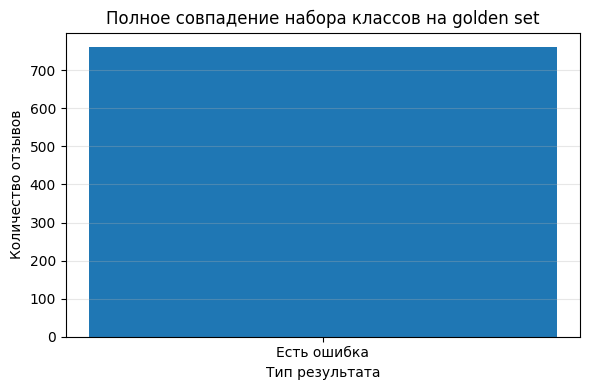

График сохранен: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures/golden_exact_match_counts.png
Ошибок для ручного анализа: 761


,text,true_labels,pred_labels,is_exact_match,probs_json
0,Бокалы пришли в рванной коробке и один бокал с...,"[""Брак / дефект товара"", ""Низкое качество мате...","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.495215505361557, ""Н..."
1,"Маловероятно, ещё и с затяжками. Не захотели в...","[""Брак / дефект товара""]","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.4813600778579712, ""..."
2,Заказ шёл долго. Катушки сломанные пришли. Нет...,"[""Проблема доставки / получения"", ""Брак / дефе...","[""Низкое качество материала"", ""Несоответствие ...",False,"{""Брак / дефект товара"": 0.44367972016334534, ..."
3,"Пришёл товар разбитый, это вообще что? Знают ч...","[""Брак / дефект товара"", ""Проблема с упаковкой""]","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.4614475667476654, ""..."
4,Никакой фирменной упаковки. Пришло в обычном п...,"[""Проблема с упаковкой"", ""Подделка / оригиналь...","[""Брак / дефект товара"", ""Несоответствие описа...",False,"{""Брак / дефект товара"": 0.46874290704727173, ..."
5,При получении коробка была мятая открыл посмот...,"[""Проблема с упаковкой"", ""Брак / дефект товара""]","[""Брак / дефект товара"", ""Несоответствие описа...",False,"{""Брак / дефект товара"": 0.5518707633018494, ""..."
6,"Контейнер пришел сломаный. Выкупать не стала, ...","[""Брак / дефект товара""]","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.4781323969364166, ""..."
7,"Пришол сломанный, за аозврат сняли 100р, вопро...","[""Брак / дефект товара"", ""Проблема доставки / ...","[""Брак / дефект товара"", ""Несоответствие описа...",False,"{""Брак / дефект товара"": 0.5428617000579834, ""..."
8,"кружка пришла разбитая, почему к возврату 88 р...","[""Брак / дефект товара"", ""Проблема доставки / ...","[""Брак / дефект товара"", ""Низкое качество мате...",False,"{""Брак / дефект товара"": 0.5123875737190247, ""..."
9,"Пришла сломанная, такое впечатление,что б/у. П...","[""Брак / дефект товара""]","[""Брак / дефект товара"", ""Несоответствие описа...",False,"{""Брак / дефект товара"": 0.5205565690994263, ""..."


In [27]:
# =========================
# График ошибок на golden set
# =========================

exact_counts = gold_predictions_df["is_exact_match"].value_counts().rename(index={True: "Полное совпадение", False: "Есть ошибка"})

plt.figure(figsize=(6, 4))
plt.bar(exact_counts.index.astype(str), exact_counts.values)
plt.title("Полное совпадение набора классов на golden set")
plt.xlabel("Тип результата")
plt.ylabel("Количество отзывов")
plt.grid(axis="y", alpha=0.3)
save_current_fig("golden_exact_match_counts.png")

error_examples = gold_predictions_df[~gold_predictions_df["is_exact_match"]].copy()
print("Ошибок для ручного анализа:", len(error_examples))
display(error_examples.head(20))


In [28]:
# Сохраняем модель, tokenizer и конфиги

MODEL_SAVE_DIR = OUTPUT_DIR / "model"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "num_labels": NUM_LABELS,
        "allowed_labels": ALLOWED_LABELS,
        "dropout": DROPOUT,
        "max_length": MAX_LENGTH,
        "thresholds": thresholds.tolist(),
    },
    MODEL_SAVE_DIR / "rubert_head_only_multilabel.pt",
)

tokenizer.save_pretrained(MODEL_SAVE_DIR / "tokenizer")

with open(MODEL_SAVE_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "allowed_labels": ALLOWED_LABELS,
            "label2id": LABEL2ID,
            "id2label": ID2LABEL,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(MODEL_SAVE_DIR / "thresholds.json", "w", encoding="utf-8") as f:
    json.dump(
        {label: float(thresholds[i]) for i, label in enumerate(ALLOWED_LABELS)},
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Модель сохранена в:", MODEL_SAVE_DIR)
print("Отчеты сохранены в:", REPORTS_DIR)


Модель сохранена в: /content/drive/MyDrive/MLops_project/project/models/rubert_head_only_multilabel/model
Отчеты сохранены в: /content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel


In [29]:
# Пример инференса

def predict_labels(text, model, tokenizer, thresholds):
    model.eval()
    encoded = tokenizer(
        normalize_text(text),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    pred_labels = [
        ALLOWED_LABELS[i]
        for i, prob in enumerate(probs)
        if prob >= thresholds[i]
    ]

    return pred_labels, {
        ALLOWED_LABELS[i]: float(probs[i])
        for i in range(NUM_LABELS)
    }


example_text = "Пришла мятая коробка, сам товар вроде целый, но упаковка ужасная."
pred_labels, probs = predict_labels(example_text, model, tokenizer, thresholds)

print("Текст:", example_text)
print("Предсказанные классы:", pred_labels)
pd.DataFrame({"label": ALLOWED_LABELS, "probability": [probs[l] for l in ALLOWED_LABELS], "threshold": thresholds})


Текст: Пришла мятая коробка, сам товар вроде целый, но упаковка ужасная.
Предсказанные классы: ['Брак / дефект товара', 'Несоответствие описанию', 'Проблема с комплектацией', 'Проблема с упаковкой']


,label,probability,threshold
0,Брак / дефект товара,0.470577,0.45
1,Низкое качество материала,0.049433,0.05
2,Проблема с размером / посадкой,0.038044,0.05
3,Несоответствие описанию,0.494527,0.40
4,Несоответствие ожиданиям / эффекту,0.416633,0.45
5,Проблема с комплектацией,0.527665,0.45
6,Проблема с упаковкой,0.556346,0.40
7,Проблема доставки / получения,0.468815,0.55
8,Цена / ценность,0.047899,0.05
9,Подделка / оригинальность,0.021301,0.05


## Что смотреть после запуска

Основные файлы с результатами появятся здесь:

```text
/content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel
```

Главные файлы:

```text
training_history.csv
validation_metrics_tuned.csv
validation_per_class_metrics.csv
golden_metrics_summary.csv
golden_per_class_metrics_tuned_thresholds.csv
golden_predictions.csv
thresholds_by_class.csv
figures/*.png
```

Сохраненная модель:

```text
/content/drive/MyDrive/MLops_project/project/models/rubert_head_only_multilabel/model/rubert_head_only_multilabel.pt
```

Главная метрика для сравнения — `golden_tuned_macro_f1`, потому что она показывает среднее качество по классам с учетом редких классов.


Графики сохраняются в папку:

```text
/content/drive/MyDrive/MLops_project/project/reports/rubert_head_only_multilabel/figures
```
